In [2]:
%pip install matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 1.7 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.2/129.2 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 13.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.2/383.2 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 10.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 12.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 11.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.4/126.4 kB 4.8 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [1]:
import sys; print(sys.prefix)

/mnt/c/Eliezer/workspace/github.com/py-inventory-v2-a2a/.venv


In [2]:
import matplotlib.pyplot as plt
import numpy as np

In [3]:
class GridCellModule:

    def __init__(self, scale, anchor_coord=None, rng_seed=42, verbose=False):
        self.scale = scale
        self.anchor_coord = anchor_coord
        self.verbose = verbose
        self.rng = np.random.default_rng(rng_seed)
        self.orientation = self.rng.uniform(0, 2 * np.pi)
        self.params = {}
        
        # 1. Define the 3 wave vectors for a hexagonal grid (120-degree offsets)
        angles = np.array([
            self.orientation, 
            self.orientation + 2 * np.pi / 3, 
            self.orientation + 4 * np.pi / 3
        ])
        self.k_x = np.cos(angles)
        self.k_y = np.sin(angles)
        
        # 2. PHASE ANCHORING LOGIC
        if self.anchor_coord is not None:
            # We calculate a unique phase for each of the 3 waves to force them 
            # to all peak simultaneously at the anchor_coord.
            # Formula: phase = -(k · x) / scale
            self.phases = -(self.k_x * anchor_coord[0] + self.k_y * anchor_coord[1]) / self.scale
        else:
            self.phases = self.rng.uniform(0, 2 * np.pi, 3)
        
        self.params = {
                "k_x": self.k_x,        # Pre-calculated
                "k_y": self.k_y,        # Pre-calculated
                "phases": self.phases,   # Pre-calculated
                "scale": self.scale,
                "orientation": self.orientation
        } 
           
    def get_grid_activation(self, X, Y):
        # We use the pre-calculated k_x, k_y and phases
        # Proj becomes a (3, res, res) array
        proj = (self.k_x[:, None, None] * X + self.k_y[:, None, None] * Y) / self.scale + self.phases[:, None, None]
        
        # Sum the three cosines
        activation = np.sum(np.cos(proj), axis=0)
        # Normalize to [0, 1]
        return (activation + 1.5) / 4.5

    def get_single_activation(self, pos):
        # Calculation for a single point
        
        proj = (self.k_x * pos[0] + self.k_y * pos[1]) / self.scale + self.phases
        activation = np.sum(np.cos(proj))
        if self.verbose:
            print(f"Calculating activation for position {pos} at scale '{self.scale}'")
            print(f"proj: {proj}")
            print(f"activation: {activation}")
        return (activation + 1.5) / 4.5

In [4]:
# 1. Setup the inventory space
NUM_CEL = 64

scale_coarse = {"SHORT": 0.125, "MEDIUM": 0.25, "LONG": 0.5}

docs = np.linspace(-1, 1, NUM_CEL)
slopes = np.linspace(-1, 1, NUM_CEL)
X, Y = np.meshgrid(docs, slopes)

# 2. Your Original Inventory Place Cells
# Where i am and place cells are the sensors
INVENTORY_PLACE_CELL = {
    "SURPLUS":  {"coords": np.array([1.0, 0.2]), "color": "pink"},
    "HIGH":     {"coords": np.array([0.7, 0.5]), "color": "cyan"},
    "BALANCED": {"coords": np.array([0.4, 0.8]), "color": "blue"},
    "LOW":      {"coords": np.array([0.2, 0.12]), "color": "yellow"},
    "CRITICAL": {"coords": np.array([0.1, 0.15]), "color": "red"},
    "RUNOUT":   {"coords": np.array([0.0, 0.2]), "color": "black"},
}

# 3 Set the Peak of the Grid Cell to the "BALANCED" Inventory Place Cell
SCALE_CHOICE = "MEDIUM"
ANCHOR_CHOICE = "BALANCED"
ANCHOR_COORD=INVENTORY_PLACE_CELL[ANCHOR_CHOICE]["coords"]

# 4. Initialize Module and compute surface
module = GridCellModule(scale=scale_coarse[SCALE_CHOICE], anchor_coord=ANCHOR_COORD, rng_seed=42)

grid_firing = module.get_grid_activation(X, Y)

print("----------------")
print(module.params)
print("----------------")
print("grid_firing" ,grid_firing)

----------------
{'k_x': array([ 0.14995256,  0.78125714, -0.9312097 ]), 'k_y': array([-0.98869319,  0.62420932,  0.36448387]), 'phases': array([ 2.92389412, -3.24748126,  0.32358715]), 'scale': 0.25, 'orientation': 4.862909272689599}
----------------
grid_firing [[0.17741542 0.20497754 0.23662663 ... 0.19206947 0.22246939 0.25474237]
 [0.18023629 0.20871235 0.24125155 ... 0.21288924 0.24506223 0.27916554]
 [0.18112875 0.21039321 0.24368266 ... 0.2332612  0.26714811 0.30301111]
 ...
 [0.37954458 0.34620819 0.31267876 ... 0.40394991 0.3602644  0.31868944]
 [0.3463294  0.31502882 0.28354569 ... 0.39072218 0.34812198 0.30764311]
 [0.31351987 0.28432782 0.25495736 ... 0.37498758 0.33362157 0.29437884]]


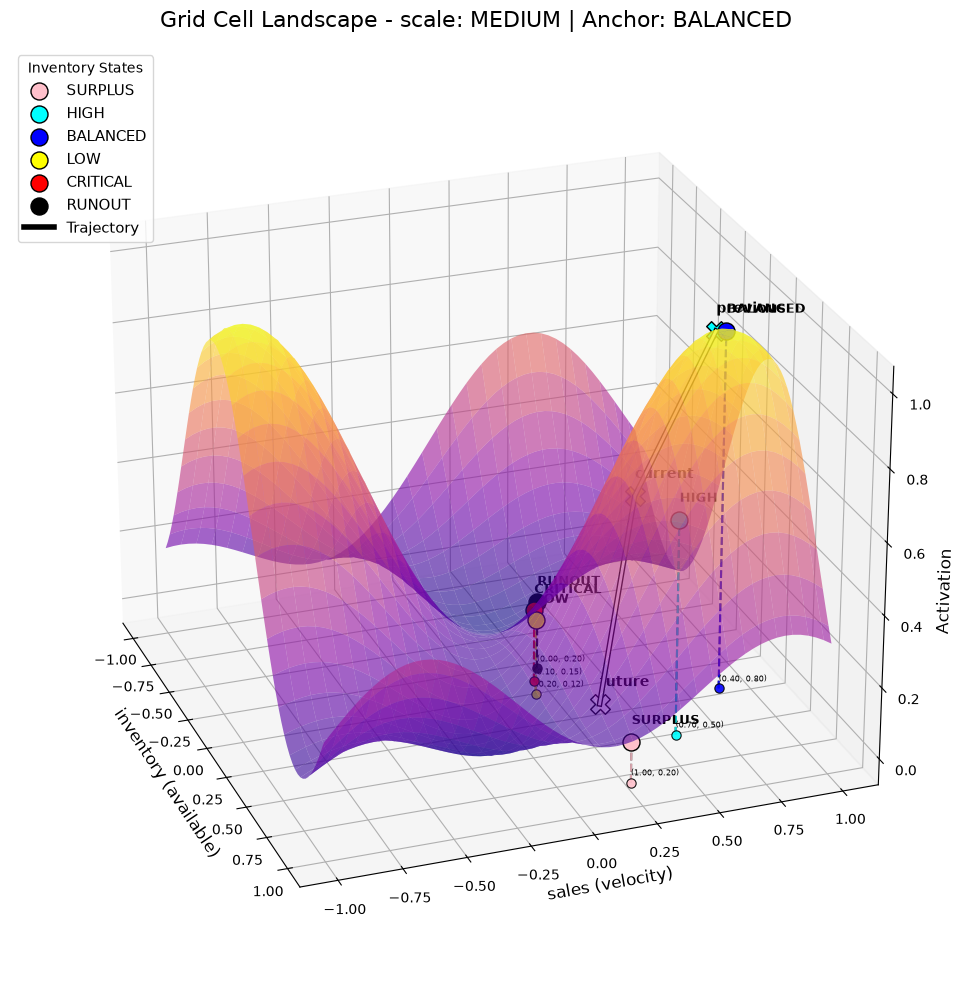

In [7]:
# 5. Add the Trajectory Path (Previous -> Current -> Future)
trajectory_points = [
    {"label": "previous", "coords": np.array([0.3, 0.8]), "color": "cyan"},
    {"label": "current", "coords": np.array([0.5, 0.4]), "color": "yellow"},
    {"label": "future", "coords": np.array([0.8, 0.15]), "color": "white"}
]

# 4. Create the 3D Plot
fig = plt.figure(figsize=(16, 10))
ax = fig.add_subplot(111, projection="3d")

# Plot the grid cell terrain
surface = ax.plot_surface(
    X,
    Y,
    grid_firing,
    cmap="plasma",
    edgecolor="none",
    alpha=0.6,
    rstride=2,
    cstride=2,
)

# 5. Plot each place cell on the terrain
for name, data in INVENTORY_PLACE_CELL.items():
    coords = data["coords"]
    z_activation = module.get_single_activation(coords)

    # Plot point
    ax.scatter(
        coords[0],
        coords[1],
        z_activation,
        color=data["color"],
        s=150,
        label=name,
        edgecolor="black",
        depthshade=False,
        zorder=10,
    )

    # Add text label slightly above the point for the place cell name
    ax.text(
        coords[0], 
        coords[1], 
        z_activation + 0.05, 
        name, 
        color='black', 
        fontsize=9, 
        fontweight='bold'
    )

    # Draw exact vertical line to the floor (same x and y, only z changes)
    ax.plot(
        [coords[0], coords[0]],
        [coords[1], coords[1]],
        [0, z_activation],
        color='black',
        linestyle="--",
        linewidth=1.5,
        alpha=0.8,
    )
        
    # Draw line to the floor
    ax.plot(
        [coords[0], coords[0]],
        [coords[1], coords[1]],
        [0, z_activation],
        color=data["color"],
        linestyle="--",
        linewidth=1.5,
        alpha=0.8,
    )
    
    # Floor projection marker to verify the line lands on the same XY coordinate
    ax.scatter(
        coords[0],
        coords[1],
        0,
        color=data["color"],
        s=45,
        marker="o",
        edgecolor="black",
        linewidth=0.8,
        alpha=0.9,
        depthshade=False,
        zorder=9,
    )
    # Floor XY coordinate label for each place cell with profit/yield
    ax.text(
        coords[0],
        coords[1],
        0.02,
        f"({coords[0]:.2f}, {coords[1]:.2f})",
        color='black',
        fontsize=6,
    )

path_x = [p["coords"][0] for p in trajectory_points]
path_y = [p["coords"][1] for p in trajectory_points]
path_z = [module.get_single_activation(p["coords"]) for p in trajectory_points]

# Plot the path line
ax.plot(path_x, path_y, path_z, color="black", linewidth=4, label="Trajectory", zorder=15)
ax.plot(path_x, path_y, path_z, color="white", linewidth=2, zorder=16) # Contrast line

# Plot the individual points in the sequence
for i, p in enumerate(trajectory_points):
    ax.scatter(
        path_x[i], path_y[i], path_z[i], 
        color=p["color"], s=200, marker='X', edgecolor='black', zorder=20
    )
    # Add text label slightly above the point
    ax.text(path_x[i], path_y[i], path_z[i] + 0.05, p["label"], 
            color='black', fontsize=10, fontweight='bold')
    
ax.set_title(
    "Grid Cell Landscape - scale: {} | Anchor: {}".format(SCALE_CHOICE, ANCHOR_CHOICE),
    fontsize=16,
    pad=15,
)

ax.set_xlabel("inventory (available)", fontsize=12)
ax.set_ylabel("sales (velocity)", fontsize=12)
ax.set_zlabel("Activation", fontsize=12)

# Rotate for better view # -20 / -60 / -80
ax.view_init(elev=25, azim=-20)

ax.legend(loc="upper left", fontsize=11, title="Inventory States")

plt.tight_layout()
plt.show()

In [8]:
INVENTORY_PLACE_CELL

{'SURPLUS': {'coords': array([1. , 0.2]), 'color': 'pink'},
 'HIGH': {'coords': array([0.7, 0.5]), 'color': 'cyan'},
 'BALANCED': {'coords': array([0.4, 0.8]), 'color': 'blue'},
 'LOW': {'coords': array([0.2 , 0.12]), 'color': 'yellow'},
 'CRITICAL': {'coords': array([0.1 , 0.15]), 'color': 'red'},
 'RUNOUT': {'coords': array([0. , 0.2]), 'color': 'black'}}

-----------------------------------------------
Execution Plan

```
PLACE CELL
     ↓
"Where am I?"
     ↓
INVENTORY_HIGH

GRID CELL
     ↓
"What is my continuous representation?"
     ↓
g_current

TEM DYNAMICS
     ↓
"Where can I move?"
     ↓
g_current → g_next
     ↓
distance / direction relative to peak

PLANNER
     ↓
"Which action produces the desired transition?"
     ↓
HOLD / REPLENISH / PRICE_UP / PRICE_DOWN / ...
```

----------------------------------------------------

### What is my continuous representation ?

```
              current_state
              (0.65, 0.40)
                    │
          ┌─────────┼─────────┐
          ↓         ↓         ↓
       SHORT     MEDIUM      LONG
          │         │         │
          ↓         ↓         ↓
         g_s       g_m       g_l
          └─────────┼─────────┘
                    ↓
          continuous representation
```

#### The grid-cell representation is the activation of the current position across the grid-cell modules.

In [7]:
def get_continuous_representation(current_state, anchor_coord):
    representations = {}
    representation = []

    for name, scale in scale_coarse.items():

        module = GridCellModule(
            scale=scale,
            anchor_coord=anchor_coord,
            rng_seed=42
        )

        activation = module.get_single_activation(current_state)

        representations[name] = activation
        representation.append(activation)

    return representations, representation

In [8]:
current_state = np.array([0.65, 0.4])

continuous_representation, g_representation = get_continuous_representation(
    current_state,
    ANCHOR_COORD
)

print("Continuous representation:", continuous_representation)
print("Representation:", g_representation)

Continuous representation: {'SHORT': np.float64(0.10326305015884918), 'MEDIUM': np.float64(0.527212763358174), 'LONG': np.float64(0.8597317355432784)}
Representation: [np.float64(0.10326305015884918), np.float64(0.527212763358174), np.float64(0.8597317355432784)]


-----------------------------------------------

What is my continuous representation?

```
current_state = (0.65, 0.40)

        ↓ Grid Cell Modules

g_current = [
    activation_SHORT,
    activation_MEDIUM,
    activation_LONG
]
```

### Where can I move?

In [9]:
def get_direction_to_peak(current_state, peak_coord):

    direction = peak_coord - current_state

    distance = np.linalg.norm(direction)

    if distance > 0:
        direction_normalized = direction / distance
    else:
        direction_normalized = np.zeros_like(direction)

    return direction, direction_normalized, distance

In [10]:
direction, direction_normalized, distance = get_direction_to_peak(
    current_state,
    ANCHOR_COORD
)

print("Current:", current_state)
print("Peak:", ANCHOR_CHOICE, ANCHOR_COORD)
print("Direction:", direction)
print("Normalized direction:", direction_normalized)
print("Distance:", distance)

Current: [0.65 0.4 ]
Peak: BALANCED [0.4 0.8]
Direction: [-0.25  0.4 ]
Normalized direction: [-0.52999894  0.8479983 ]
Distance: 0.47169905660283024


---------------------------------------------

Normalized direction: [-0.52999894  0.8479983 ]

inventory_available:
    decrease

sales_velocity:
    increase

to move directly toward the BALANCED anchor

In [11]:
def get_grid_representation(current_state):
    representation = []
    
    for name, scale in scale_coarse.items():

        module = GridCellModule(
            scale=scale,
            anchor_coord=ANCHOR_COORD,
            rng_seed=42
        )

        activation = module.get_single_activation(current_state)

        representation.append(activation)

    return np.array(representation)

In [12]:
g_current = get_grid_representation(current_state)
g_peak = get_grid_representation(ANCHOR_COORD)

print("g_current:", g_current)
print("g_peak:", g_peak)

g_current: [0.10326305 0.52721276 0.85973174]
g_peak: [1. 1. 1.]


--------------------------------------

#### A useful "where can I move?" experiment

sample points along the direction toward the peak

In [13]:
def generate_path_to_peak(current_state,peak_coord,steps=10):
    path = []

    for t in np.linspace(0.0, 1.0, steps):

        position = ( current_state + t * (peak_coord - current_state))

        path.append(position)

    return np.array(path)

In [14]:
path = generate_path_to_peak(current_state, ANCHOR_COORD,steps=10)

for i, position in enumerate(path):

    grid_state = get_grid_representation(position)

    print(
        f"step={i:02d}",
        f"position={position}",
        f"grid={grid_state}"
    )

step=00 position=[0.65 0.4 ] grid=[0.10326305 0.52721276 0.85973174]
step=01 position=[0.62222222 0.44444444] grid=[0.1172056  0.6078941  0.88785747]
step=02 position=[0.59444444 0.48888889] grid=[0.18556958 0.68679239 0.91324559]
step=03 position=[0.56666667 0.53333333] grid=[0.30037194 0.76133874 0.93568747]
step=04 position=[0.53888889 0.57777778] grid=[0.44736639 0.82909939 0.95499859]
step=05 position=[0.51111111 0.62222222] grid=[0.6078941  0.88785747 0.97102008]
step=06 position=[0.48333333 0.66666667] grid=[0.76133874 0.93568747 0.98362013]
step=07 position=[0.45555556 0.71111111] grid=[0.88785747 0.97102008 0.992695  ]
step=08 position=[0.42777778 0.75555556] grid=[0.97102008 0.992695   0.99816998]
step=09 position=[0.4 0.8] grid=[1. 1. 1.]


---------------------------------------------------

- Your current state has a continuous trajectory toward the BALANCED anchor:


```
STATE SPACE

sales velocity
      ↑
 0.8  |                    ★ BALANCED
      |                  [1,1,1]
      |               ↗
      |            ↗
      |         ↗
 0.4  |  ● START
      |
      +--------------------------------→ inventory
         0.4                         0.65
```
For your trajectory:

     START  = [0.65, 0.40]
     TARGET = [0.40, 0.80]

the total Euclidean distance is approximately:

     0.472

With 10 points, there are actually 9 intervals, so each movement is approximately:

     0.472 / 9 ≈ 0.0524

With 15 points, there are 14 intervals:

     0.472 / 14 ≈ 0.0337

At that point, the number of steps could come from your problem:

     10 minutes
     10 inventory-update cycles
     10 sales observations
     10 predicted transitions
     10 planning horizons

```
HIGH
 ● current
   \
    \
     \
      \
       ● BALANCED
         peak
```

One important distinction

At this stage, your answer to "Where can I move?" is not yet an action.

It is a geometric answer:

- Current: (0.65, 0.40)

- Peak: (0.40, 0.80)

- Direction: (-0.53, +0.85)

- Trajectory: current → BALANCED

------------------------------------------------------

### geometric answer:

- Current:(0.65, 0.40)

- Peak:(0.40, 0.80)

- Direction:(-0.53, +0.85)

- Trajectory: current → BALANCED

### 1 WHERE AM I?
```
current_state
    ↓
place cells
    ↓
HIGH
```
### 2 WHAT IS MY CONTINUOUS REPRESENTATION?
```
current_state
    ↓
grid modules
    ↓
g_current = [g_short, g_medium, g_long]
```
### 3. WHERE CAN I MOVE?
```
g_current
    ↓
TEM geometry
    ↓
peak = BALANCED
    ↓
direction = (-0.53, +0.85)
    ↓
trajectory toward BALANCED
```

### which action causes you to move there

In [15]:
from enum import Enum

# Define your actions
class Action(Enum):
    HOLD = "HOLD"
    REPLENISH = "REPLENISH"
    CLEARANCE = "CLEARANCE"
    INCREASE_PRICE = "INCREASE_PRICE"
    DECREASE_PRICE = "DECREASE_PRICE"

# Define the effects of each action on the inventory state
ACTION_EFFECTS = {
    Action.HOLD: np.array([0.00,  0.00]),
    
    # More inventory, but sales velocity doesn't directly change
    Action.REPLENISH: np.array([0.15, 0.00]),

    # Inventory decreases and sales velocity increases
    Action.CLEARANCE: np.array([-0.15, 0.20]),

    # Higher price -> slower sales
    Action.INCREASE_PRICE: np.array([0.00, -0.10]),

    # Lower price -> faster sales
    Action.DECREASE_PRICE: np.array([0.00,  0.15]),
}

In [16]:
def T(state, action):
    """
    Action-conditioned transition:

        T(state, action) -> next_state
    """

    effect = ACTION_EFFECTS[action]

    next_state = state + effect

    # Keep the state inside our [0, 1] state space
    next_state = np.clip(next_state, 0.0, 1.0)

    return next_state

In [17]:
current_state = np.array([0.65, 0.40])

for action in Action:
    next_state = T(current_state, action)

    print(
        f"{action.value:20s}"
        f" current={current_state}"
        f" -> next={next_state}"
    )

HOLD                 current=[0.65 0.4 ] -> next=[0.65 0.4 ]
REPLENISH            current=[0.65 0.4 ] -> next=[0.8 0.4]
CLEARANCE            current=[0.65 0.4 ] -> next=[0.5 0.6]
INCREASE_PRICE       current=[0.65 0.4 ] -> next=[0.65 0.3 ]
DECREASE_PRICE       current=[0.65 0.4 ] -> next=[0.65 0.55]


----------------------------------------

```
                    STATE SPACE

                  sales velocity
                        ↑
                        |
                  BALANCED (0.4, 0.8)
                        ★
                        |
                        |       ← DECREASE_PRICE
                        |
             current ● (0.65, 0.40)
                        |
                        |
                        +------------------------→ inventory
```

In [18]:
def get_grid_representation(state, anchor_coord):
    representation = []

    for _, scale in scale_coarse.items():

        module = GridCellModule(
            scale=scale,
            anchor_coord=anchor_coord,
            rng_seed=42
        )

        activation = module.get_single_activation(state)

        representation.append(activation)

    return np.array(representation)

In [21]:
g_current = get_grid_representation(
    current_state,
    ANCHOR_COORD
)
print("Grid representation of the current state:", g_current)

Grid representation of the current state: [0.10326305 0.52721276 0.85973174]


In [22]:
next_state = T(current_state, action)

g_next = get_grid_representation(
    next_state,
    ANCHOR_COORD
)

print("Grid representation of the next state:", g_next)

Grid representation of the next state: [0.21099716 0.70625862 0.91923774]


In [23]:
for action in Action:

    # 1. Current physical/semantic state
    current_state = np.array([0.65, 0.40])

    # 2. Predict where this action takes us
    next_state = T(current_state, action)

    # 3. Encode predicted state into grid representation
    g_current = get_grid_representation(
        current_state,
        ANCHOR_COORD
    )

    g_next = get_grid_representation(
        next_state,
        ANCHOR_COORD
    )

    print(f"\nACTION: {action.value}")
    print("g_current:", g_current)
    print("g_next:   ", g_next)


ACTION: HOLD
g_current: [0.10326305 0.52721276 0.85973174]
g_next:    [0.10326305 0.52721276 0.85973174]

ACTION: REPLENISH
g_current: [0.10326305 0.52721276 0.85973174]
g_next:    [0.21408134 0.38638509 0.80318402]

ACTION: CLEARANCE
g_current: [0.10326305 0.52721276 0.85973174]
g_next:    [0.56456724 0.87319139 0.9670811 ]

ACTION: INCREASE_PRICE
g_current: [0.10326305 0.52721276 0.85973174]
g_next:    [0.14853389 0.39451874 0.80740485]

ACTION: DECREASE_PRICE
g_current: [0.10326305 0.52721276 0.85973174]
g_next:    [0.21099716 0.70625862 0.91923774]


------------------------------------------------

```
                 action
                   │
                   ▼
          ┌─────────────────┐
g_current │       T         │ g_next
─────────►│                 │─────────►
          └─────────────────┘
          
          
current state
(0.65, 0.40)
      │
      ▼
g_current
      │
      │ + action
      ▼
T(g_current, action)
      │
      ▼
g_next
      │
      ▼
predicted state          
```          

In [24]:
def distance_to_target(state, target):
    return np.linalg.norm(state - target)

In [25]:
target_state = ANCHOR_COORD

for action in Action:

    next_state = T(current_state, action)

    distance = distance_to_target(
        next_state,
        target_state
    )

    print(
        f"{action.value:20s}"
        f" next={next_state}"
        f" distance={distance:.4f}"
    )

HOLD                 next=[0.65 0.4 ] distance=0.4717
REPLENISH            next=[0.8 0.4] distance=0.5657
CLEARANCE            next=[0.5 0.6] distance=0.2236
INCREASE_PRICE       next=[0.65 0.3 ] distance=0.5590
DECREASE_PRICE       next=[0.65 0.55] distance=0.3536


-------------------------
```                 
                 ┌───────────────┐
                 │ current state │
                 │  (0.65, 0.40) │
                 └───────┬───────┘
                         │
                         ▼
                    g_current
                         │
              ┌──────────┼──────────┐
              │          │          │
           HOLD      CLEARANCE   DECREASE
              │          │          │
              ▼          ▼          ▼
           T(g,a)      T(g,a)     T(g,a)
              │          │          │
              ▼          ▼          ▼
            g_next     g_next     g_next
              │          │          │
              └──────────┼──────────┘
                         ▼
                  compare with
                    BALANCED
                         │
                         ▼
                  choose action
```

| Action         | Next state     | Distance to BALANCED | Grid `g_next`           |
| -------------- | -------------- | -------------------: | ----------------------- |
| HOLD           | `[0.65, 0.40]` |             `0.4717` | `[0.103, 0.527, 0.860]` |
| REPLENISH      | `[0.80, 0.40]` |             `0.5657` | `[0.214, 0.386, 0.803]` |
| CLEARANCE      | `[0.50, 0.60]` |             `0.2236` | `[0.565, 0.873, 0.967]` |
| INCREASE_PRICE | `[0.65, 0.30]` |             `0.5590` | `[0.149, 0.395, 0.807]` |
| DECREASE_PRICE | `[0.65, 0.55]` |             `0.3536` | `[0.211, 0.706, 0.919]` |

```
distance

CLEARANCE       0.2236  ← closer
DECREASE_PRICE  0.3536  ← closer
HOLD            0.4717  ← unchanged
INCREASE_PRICE  0.5590  ← farther
REPLENISH       0.5657  ← farther
```

This does NOT mean "CLEARANCE is the correct action."

It only means:

Under the transition assumptions you manually defined, CLEARANCE produces the next state that is geometrically closest to your chosen BALANCED anchor.

That's a geometric insight, not yet a business decision.

For example, perhaps inventory 0.50 is actually too low, and replenishment is necessary for another business reason. Your current model doesn't know that.

```
                  current
                [0.65, 0.40]
                     |
        ┌────────────┼─────────────┐
        ↓            ↓             ↓
    REPLENISH     CLEARANCE    DECREASE_PRICE
        ↓            ↓             ↓
   [0.80,0.40]  [0.50,0.60]   [0.65,0.55]
        ↓            ↓             ↓
     farther       closer        closer
     target        target        target


     g_current
   |
   ├── REPLENISH ──────→ [0.214, 0.386, 0.803]
   |
   ├── CLEARANCE ──────→ [0.565, 0.873, 0.967]
   |
   └── DECREASE_PRICE ─→ [0.211, 0.706, 0.919]

```

progress = current_distance - next_distance

   HOLD
    0.4717 - 0.4717 =  0.0000

   REPLENISH
      0.4717 - 0.5657 = -0.0940

   CLEARANCE
      0.4717 - 0.2236 = +0.2481

   INCREASE_PRICE
      0.4717 - 0.5590 = -0.0873

   DECREASE_PRICE
      0.4717 - 0.3536 = +0.1181


## First convert your data into transitions

In [19]:

trajectory = [
    # time, inventory, velocity, action
    (0,  0.50, 0.50, "HOLD"),
    (1,  0.40, 0.60, "HOLD"),
    (2,  0.35, 0.50, "HOLD"),
    (3,  0.25, 0.30, "REPLENISH"),
    (4,  0.19, 0.20, "REPLENISH"),
    (5,  1.00, 0.10, "HOLD"),
    (6,  0.90, 0.20, "DECREASE_PRICE"),
    (7,  0.80, 0.10, "DECREASE_PRICE"),
    (8,  0.80, 0.00, "CLEARANCE"),
    (9,  0.70, 0.50, "CLEARANCE"),
    (10, 0.65, 1.00, "INCREASE_PRICE"),
    (11, 0.50, 0.60, "HOLD"),
]

ACTIONS = {
    "HOLD": 0,
    "REPLENISH": 1,
    "CLEARANCE": 2,
    "INCREASE_PRICE": 3,
    "DECREASE_PRICE": 4,
}

def build_transitions(trajectory):
    transitions = []

    for i in range(len(trajectory) - 1):

        _, inventory, velocity, action = trajectory[i]

        _, next_inventory, next_velocity, _ = trajectory[i + 1]

        state = np.array([
            inventory,
            velocity
        ], dtype=np.float32)

        next_state = np.array([
            next_inventory,
            next_velocity
        ], dtype=np.float32)

        transitions.append({
            "state": state,
            "action": ACTIONS[action],
            "action_description": action,
            "next_state": next_state
        })

    return transitions

In [20]:
transitions = build_transitions(trajectory)
transitions

[{'state': array([0.5, 0.5], dtype=float32),
  'action': 0,
  'action_description': 'HOLD',
  'next_state': array([0.4, 0.6], dtype=float32)},
 {'state': array([0.4, 0.6], dtype=float32),
  'action': 0,
  'action_description': 'HOLD',
  'next_state': array([0.35, 0.5 ], dtype=float32)},
 {'state': array([0.35, 0.5 ], dtype=float32),
  'action': 0,
  'action_description': 'HOLD',
  'next_state': array([0.25, 0.3 ], dtype=float32)},
 {'state': array([0.25, 0.3 ], dtype=float32),
  'action': 1,
  'action_description': 'REPLENISH',
  'next_state': array([0.19, 0.2 ], dtype=float32)},
 {'state': array([0.19, 0.2 ], dtype=float32),
  'action': 1,
  'action_description': 'REPLENISH',
  'next_state': array([1. , 0.1], dtype=float32)},
 {'state': array([1. , 0.1], dtype=float32),
  'action': 0,
  'action_description': 'HOLD',
  'next_state': array([0.9, 0.2], dtype=float32)},
 {'state': array([0.9, 0.2], dtype=float32),
  'action': 4,
  'action_description': 'DECREASE_PRICE',
  'next_state': ar

In [21]:
def find_transition(transitions, current_state):
    for transition in transitions:
        if np.allclose(
            transition["state"],
            current_state
        ):
            return transition

    return None

In [22]:
current_state = np.array([0.5, 0.5])

transition = find_transition(transitions,current_state)

print(transition)

{'state': array([0.5, 0.5], dtype=float32), 'action': 0, 'action_description': 'HOLD', 'next_state': array([0.4, 0.6], dtype=float32)}


In [23]:
def predict_from_history(transitions, state, action):
    for t in transitions:
        if np.allclose(t["state"], state) and t["action"] == action:
            return t["next_state"]

    return None

In [24]:
current_state = np.array([0.51, 0.49])

history_predicted_next = predict_from_history(transitions, current_state, ACTIONS["HOLD"])

print(history_predicted_next)


None


t0 → t1
[0.50, 0.50] + HOLD → [0.40, 0.60]

t1 → t2
[0.40, 0.60] + HOLD → [0.35, 0.50]

t2 → t3
[0.35, 0.50] + HOLD → [0.25, 0.30]

...

```

             end / t1
                ●
              /
            /
          ●   ← current state
        /
      /
    ●
 start / t0

 t1 = (0.40, 0.60)
          \
           \
            ● (0.34,0.56)
             \
              \
              t2 = (0.35,0.50)
 ```

In [ ]:
trajectory = [
    ("t0",  1.00, 0.00, "CLEARANCE"),
    ("t1",  0.95, 0.15, "CLEARANCE"),
    ("t2",  0.85, 0.25, "DECREASE_PRICE"),
    ("t3",  0.75, 0.35, "DECREASE_PRICE"),
    ("t4",  0.65, 0.45, "HOLD"),
    ("t5",  0.55, 0.40, "HOLD"),
    ("t6",  0.45, 0.55, "INCREASE_PRICE"),
    ("t7",  0.35, 0.65, "INCREASE_PRICE"),
    ("t8",  0.25, 0.75, "REPLENISH"),
    ("t9",  0.15, 0.85, "REPLENISH"),
    ("t10", 0.05, 0.95, "SELL_OFF"),
    ("t11", 0.00, 1.00, "SELL_OFF"),
    ("t12", 1.00, 1.00, "HOLD."),
    ("t13", 0.95, 0.95, "HOLD."),
    ("t14", 0.85, 0.85, "INCREASE_PRICE."),
    ("t15", 0.75, 0.75, "INCREASE_PRICE."),
    ("t16", 0.65, 0.65, "INCREASE_PRICE."),
    ("t17", 0.55, 0.55, "INCREASE_PRICE."),
    ("t18", 0.45, 0.45, "INCREASE_PRICE 2x."),    
    ("t19", 0.35, 0.35, "INCREASE_PRICE 2x."),
    ("t20", 0.25, 0.25, "REPLENISH."),
    ("t21", 0.15, 0.15, "REPLENISH."),
    ("t22", 0.05, 0.05, "SELL_OFF."),
    ("t23", 0.00, 0.00, "SELL_OFF."),
]

def build_transitions(trajectory):
    transitions = []

    for i in range(len(trajectory) - 1):

        current = trajectory[i]
        next_ = trajectory[i + 1]

        transitions.append({
            "from_time": current[0],
            "to_time": next_[0],

            "state": np.array(
                [current[1], current[2]],
                dtype=np.float32
            ),

            "action": current[3],

            "next_state": np.array(
                [next_[1], next_[2]],
                dtype=np.float32
            )
        })

    return transitions

def distance_to_segment(point, start, end):

    segment = end - start

    segment_length_squared = np.dot(segment, segment)

    # Degenerate segment
    if segment_length_squared == 0:
        return np.linalg.norm(point - start)

    # Position of the projection on the segment
    t = np.dot(point - start, segment) / segment_length_squared

    # Keep projection between start and end
    t = np.clip(t, 0.0, 1.0)

    projection = start + t * segment

    distance = np.linalg.norm(point - projection)

    return distance

def predict_next_state(transitions, current_state, action=None, max_distance=0.05 ):

    candidates = transitions

    if action is not None:
        candidates = [
            t for t in transitions
            if t["action"] == action
        ]

    best_transition = None
    best_distance = float("inf")

    for transition in candidates:
        distance = distance_to_segment(
            current_state,
            transition["state"],
            transition["next_state"]
        )

        if distance < best_distance:
            best_distance = distance
            best_transition = transition

    if best_transition is None:
        print("No suitable transition found.")
        return best_transition, best_distance

    print("Best transition so far:", best_transition, "with distance:", best_distance)
    print("best_distance/max_distance:", best_distance, max_distance)

    if best_distance > max_distance:
        print("Best distance exceeds max distance. No suitable transition found.")
        return best_transition, best_distance

    return best_transition, best_distance

                   t1
                   ●
                 / |
               /   |
             /     |  ← transition region
           /       |
         /         |
       ●-----------+
      t0

In [17]:
transitions = build_transitions(trajectory)

current_state = np.array([0.99, 0.49])

transition, distance = predict_next_state(
    transitions,
    current_state,
    max_distance=0.10
)

print("--------------------------------------------------")
print("Current:", current_state)
print("Matched transition:",transition["from_time"], "→", transition["to_time"])
print("Action:", transition["action"])
print("Predicted next:", transition["next_state"])
print("Distance:", distance)

Best transition so far: {'from_time': 't2', 'to_time': 't3', 'state': array([0.85, 0.25], dtype=float32), 'action': 'DECREASE_PRICE', 'next_state': array([0.75, 0.35], dtype=float32)} with distance: 0.2687005705288594
best_distance/max_distance: 0.2687005705288594 0.1
Best distance exceeds max distance. No suitable transition found.
--------------------------------------------------
Current: [0.99 0.49]
Matched transition: t2 → t3
Action: DECREASE_PRICE
Predicted next: [0.75 0.35]
Distance: 0.2687005705288594


In [39]:
current = np.array([0.34, 0.56])

result = predict_next_state(
    transitions,
    current,
    action="HOLD"
)

if result:
    transition, distance = result

    print("Action:", transition["action"])
    print("Prediction:", transition["next_state"])
    print("Distance:", distance)
else:
    print("No suitable transition found.")

Best transition so far: {'from_time': 't5', 'to_time': 't6', 'state': array([0.55, 0.4 ], dtype=float32), 'action': 'HOLD', 'next_state': array([0.45, 0.55], dtype=float32)} with distance: 0.11045359722063075
best_distance/max_distance: 0.11045359722063075 0.05
Best distance exceeds max distance. No suitable transition found.
No suitable transition found.
